# Spotify Tracks — Análise Exploratória (Dataset Limpo)

**Grupo 4 — Insights Spotify**

Este notebook roda sobre as bases processadas pelo notebook `01_limpeza_dataset.ipynb`:
- `data/processed/spotify_tracks_limpo.parquet` (ou `.csv`): **89.740 faixas únicas × 32 colunas** (grão: uma linha por `track_id`).
- `data/processed/spotify_tracks_genero_long.parquet`: **113.549 pares faixa × gênero** (grão: faixa × gênero, sem duplicações espúrias).

> **Por que um notebook sobre dados limpos?** O notebook exploratório preliminar (`Challenge_0_Spotify_Data_G4.ipynb`)
> rodou sobre o dataset bruto (114k linhas), no qual uma mesma música se repetia em até 9 gêneros diferentes.
> Isso inflava contagens e distorcia correlações e médias. Aqui, cada faixa conta exatamente uma vez no grão de faixa,
> e as análises de gênero utilizam a versão longa desduplicada.

## 0. Setup e Configuração Visual

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

RAIZ = Path.cwd()
while not (RAIZ / "dataset2(in).csv").exists() and RAIZ != RAIZ.parent:
    RAIZ = RAIZ.parent

DIR_DADOS = RAIZ / "data" / "processed"

# Carregamento do dataset consolidado no grão de faixa
if (DIR_DADOS / "spotify_tracks_limpo.parquet").exists():
    df = pd.read_parquet(DIR_DADOS / "spotify_tracks_limpo.parquet")
else:
    df = pd.read_csv(DIR_DADOS / "spotify_tracks_limpo.csv")

# Carregamento do dataset no grão faixa x gênero (longo)
df_long = pd.read_parquet(DIR_DADOS / "spotify_tracks_genero_long.parquet")

print(f"Dataset principal (faixas únicas): {len(df):,} linhas x {df.shape[1]} colunas")
print(f"Dataset longo (faixa x gênero)    : {len(df_long):,} linhas x {df_long.shape[1]} colunas")
print(f"track_id único no principal       : {df['track_id'].is_unique}")

Dataset principal (faixas únicas): 89,740 linhas x 32 colunas
Dataset longo (faixa x gênero)    : 113,549 linhas x 20 colunas
track_id único no principal       : True


In [2]:
# Configuração de estilo padronizada para dataviz de alta legibilidade
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
           "#e87ba4", "#008300", "#4a3aa7", "#e34948"]

mpl.rcParams.update({
    "font.sans-serif": ["DejaVu Sans", "Arial", "Helvetica", "sans-serif"],
    "font.family": "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#52514e",
    "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
    "axes.grid": True,
    "grid.color": "#e1e0d9",
    "grid.linewidth": 0.6,
    "grid.alpha": 0.7,
})

## 1. Panorama e Verificação de Integridade

Conferimos a aderência ao `log_limpeza.csv` e inspecionamos nulos residuais.

In [3]:
log = pd.read_csv(DIR_DADOS / "log_limpeza.csv")
print("Histórico das etapas de limpeza:")
display(log)
print()
print(f"Bruto: {log['antes'].iloc[0]:,} → Limpo: {len(df):,} faixas únicas")
assert len(df) == 89_740, "Contagem diverge do esperado (89.740)"
print("Integridade confirmada: 89.740 faixas únicas.")

Histórico das etapas de limpeza:


,etapa,antes,depois,removidas
0,Sem identificacao,114000,113999,1
1,Duplicatas exatas,113999,113549,450
2,"(track_id, genero) repetidos",113549,113549,0
3,Consolidacao por faixa,113549,89740,23809



Bruto: 114,000 → Limpo: 89,740 faixas únicas
Integridade confirmada: 89.740 faixas únicas.


In [4]:
# Nulos residuais - esperados estritamente nas sentinelas convertidas (tempo e time_signature)
nulos = df.isna().sum()
nulos = nulos[nulos > 0].to_frame("nulos")
nulos["%"] = (nulos["nulos"] / len(df) * 100).round(3)
display(nulos)

,nulos,%
tempo,157,0.175
time_signature,1008,1.123


## 2. Variáveis Numéricas e Distribuições

Resumo estatístico das principais métricas acústicas e descritivas.

In [5]:
FEATURES = ["danceability", "energy", "loudness", "speechiness",
            "acousticness", "instrumentalness", "liveness", "valence", "tempo"]

display(df[FEATURES].describe().round(3).T)

,count,mean,std,min,25%,50%,75%,max
danceability,89740.0,0.562,0.177,0.000,0.450,0.576,0.692,0.985
energy,89740.0,0.634,0.257,0.000,0.457,0.676,0.853,1.000
loudness,89740.0,-8.499,5.222,-49.531,-10.322,-7.185,-5.108,4.532
speechiness,89740.0,0.087,0.113,0.000,0.036,0.049,0.086,0.965
acousticness,89740.0,0.328,0.338,0.000,0.017,0.188,0.625,0.996
instrumentalness,89740.0,0.173,0.324,0.000,0.000,0.000,0.098,1.000
liveness,89740.0,0.217,0.195,0.000,0.098,0.132,0.279,1.000
valence,89740.0,0.469,0.263,0.000,0.249,0.457,0.682,0.995
tempo,89583.0,122.272,29.707,30.200,99.515,122.021,140.087,243.372


### 2.1 Histogramas das Features de Áudio

Grid 3×3 cobrindo as 9 métricas sonoras fundamentais.

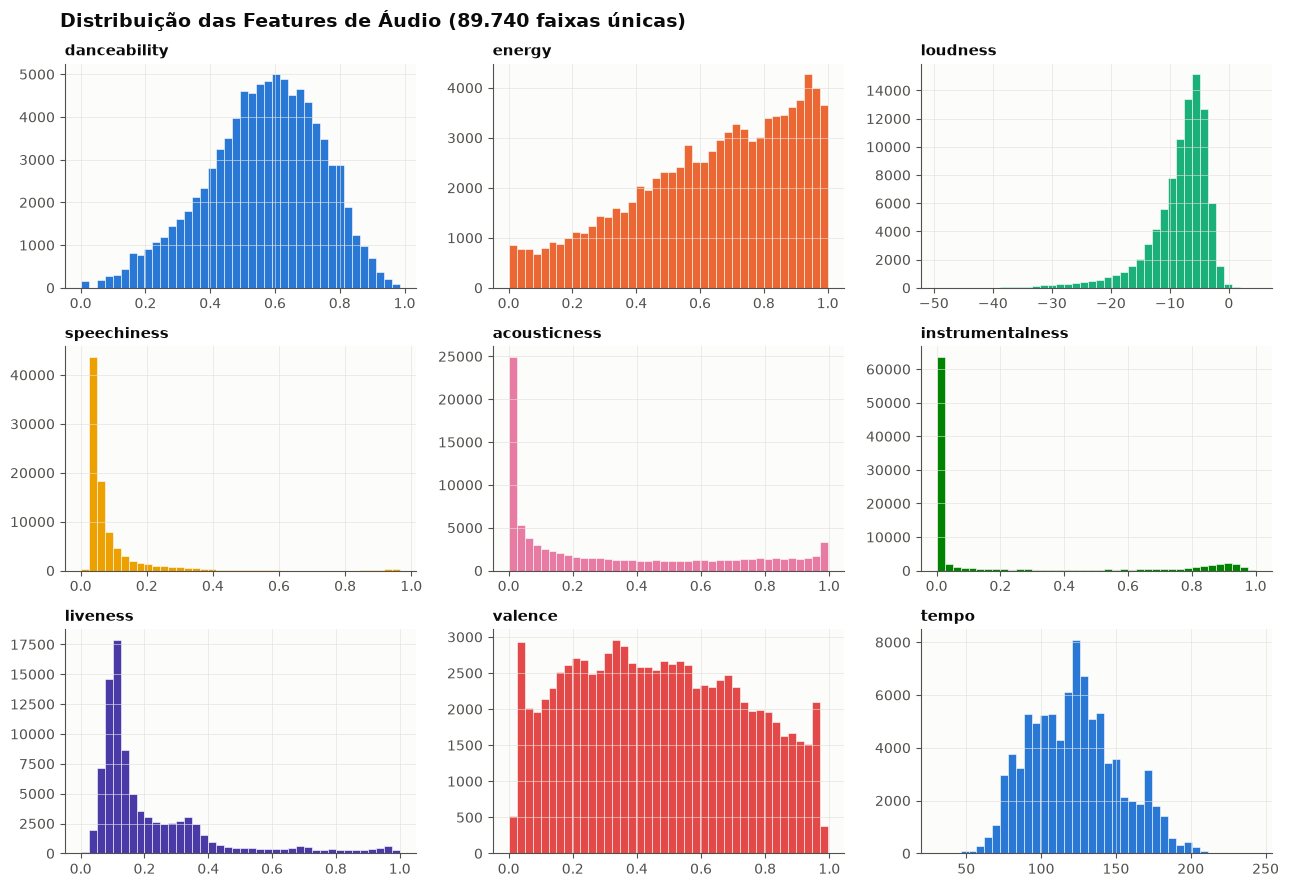

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(13, 9))
for ax, feat, cor in zip(axes.flat, FEATURES, PALETTE * 2):
    ax.hist(df[feat].dropna(), bins=40, color=cor, edgecolor="white", linewidth=0.4)
    ax.set_title(feat, loc="left", fontsize=11, color="#0b0b0b", fontweight="bold")
    ax.set_facecolor("#fcfcfb")

fig.suptitle("Distribuição das Features de Áudio (89.740 faixas únicas)",
             x=0.05, ha="left", fontsize=14, color="#0b0b0b", fontweight="bold")
fig.tight_layout()
plt.show()

### 2.2 Distribuição de Popularidade

A popularidade concentra-se em faixas baixas e médias, com **10,4% das faixas com 0 streams** (`popularity == 0`) e apenas **1,4% no topo viral** (`popularity >= 76`).

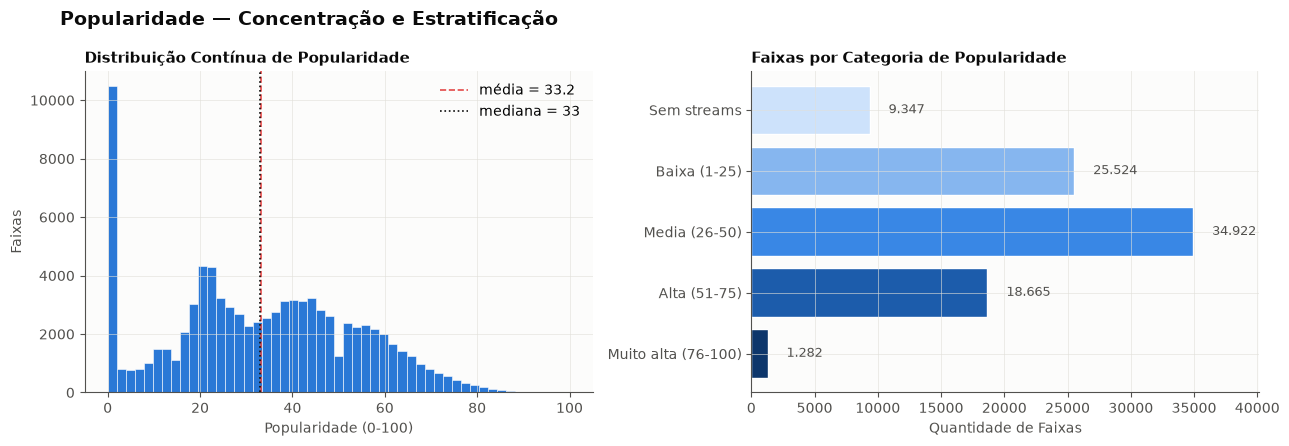

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(df["popularity"], bins=51, color="#2a78d6", edgecolor="white", linewidth=0.4)
axes[0].axvline(df["popularity"].mean(), color="#e34948", linestyle="--", linewidth=1.2,
                label=f"média = {df['popularity'].mean():.1f}")
axes[0].axvline(df["popularity"].median(), color="#0b0b0b", linestyle=":", linewidth=1.2,
                label=f"mediana = {df['popularity'].median():.0f}")
axes[0].set_title("Distribuição Contínua de Popularidade", loc="left",
                  fontsize=11, color="#0b0b0b", fontweight="bold")
axes[0].set_xlabel("Popularidade (0-100)")
axes[0].set_ylabel("Faixas")
axes[0].legend(frameon=False, loc="upper right")
axes[0].set_facecolor("#fcfcfb")

ordem = ["Sem streams", "Baixa (1-25)", "Media (26-50)", "Alta (51-75)", "Muito alta (76-100)"]
cont = df["popularidade_faixa"].value_counts().reindex(ordem)
cores = ["#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"]
axes[1].barh(cont.index, cont.values, color=cores, edgecolor="white")
axes[1].set_title("Faixas por Categoria de Popularidade", loc="left",
                  fontsize=11, color="#0b0b0b", fontweight="bold")
axes[1].set_xlabel("Quantidade de Faixas")
for i, v in enumerate(cont.values):
    axes[1].text(v + 1500, i, f"{v:,}".replace(",", "."), va="center", fontsize=9, color="#52514e")
axes[1].invert_yaxis()
axes[1].set_xlim(0, cont.max() * 1.15)
axes[1].set_facecolor("#fcfcfb")

fig.suptitle("Popularidade — Concentração e Estratificação",
             x=0.05, ha="left", fontsize=14, color="#0b0b0b", fontweight="bold")
fig.tight_layout()
plt.show()

## 3. O "DNA de um Hit" — Fatores de Sucesso e Popularidade

Comparamos as músicas mais tocadas com o restante do catálogo para identificar os padrões acústicos e emocionais que definem o sucesso na plataforma.

### 3.1 Top 5% (Hits) vs. Resto do Catálogo

Isolando o percentil 95 de popularidade (`popularity >= 67`), medimos o desvio percentual de cada métrica.

,Top 5% Hits (pop >= 67),Resto do Catálogo,Diferença (%)
danceability,0.614,0.559,9.763
energy,0.660,0.633,4.171
loudness,-6.896,-8.584,19.669
speechiness,0.081,0.088,-8.212
acousticness,0.243,0.333,-26.846
instrumentalness,0.039,0.181,-78.317
liveness,0.176,0.219,-19.863
valence,0.507,0.467,8.533
tempo,121.226,122.328,-0.901
duracao_min,3.637,3.829,-5.006


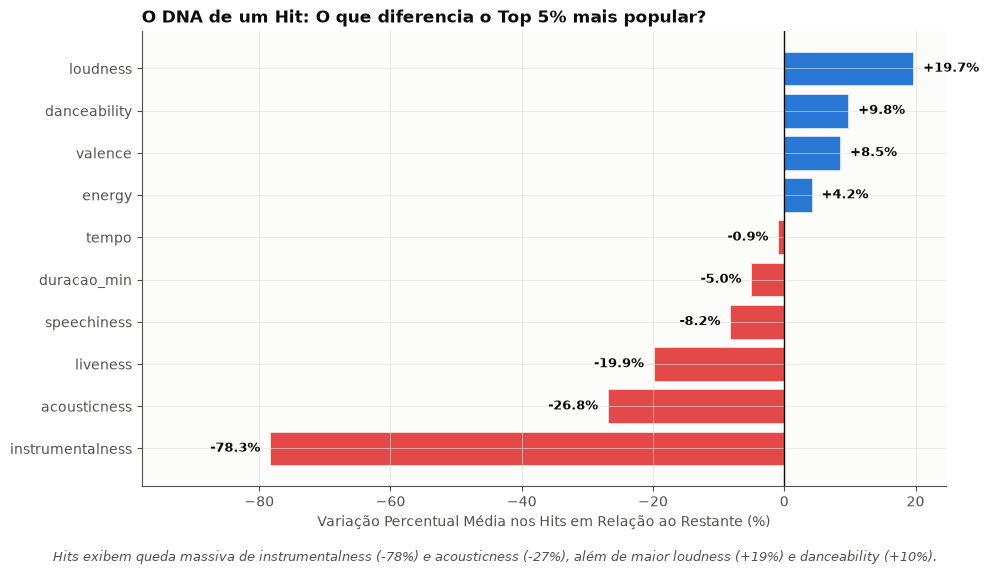

In [8]:
p95 = df["popularity"].quantile(0.95)
df["eh_hit"] = df["popularity"] >= p95

feats_hit = ["danceability", "energy", "loudness", "speechiness",
             "acousticness", "instrumentalness", "liveness", "valence", "tempo", "duracao_min"]

comp_hit = pd.DataFrame({
    "Top 5% Hits (pop >= 67)": df[df["eh_hit"]][feats_hit].mean(),
    "Resto do Catálogo": df[~df["eh_hit"]][feats_hit].mean()
})
comp_hit["Diferença (%)"] = ((comp_hit["Top 5% Hits (pop >= 67)"] - comp_hit["Resto do Catálogo"]) / comp_hit["Resto do Catálogo"].abs() * 100)

display(comp_hit.round(3))

# Gráfico de desvio percentual
fig, ax = plt.subplots(figsize=(10, 5.5))
diff = comp_hit["Diferença (%)"].sort_values()
cores = ["#e34948" if v < 0 else "#2a78d6" for v in diff.values]
ax.barh(diff.index, diff.values, color=cores, edgecolor="white", linewidth=0.4)
ax.axvline(0, color="#0b0b0b", linewidth=1)
for i, v in enumerate(diff.values):
    ax.text(v + (1.5 if v >= 0 else -1.5), i, f"{v:+.1f}%",
            va="center", ha="left" if v >= 0 else "right",
            fontsize=9, color="#0b0b0b", fontweight="bold")

ax.set_xlim(diff.min() * 1.25, diff.max() * 1.25)
ax.set_xlabel("Variação Percentual Média nos Hits em Relação ao Restante (%)")
ax.set_title("O DNA de um Hit: O que diferencia o Top 5% mais popular?",
             loc="left", fontsize=12, color="#0b0b0b", fontweight="bold")
ax.set_facecolor("#fcfcfb")
fig.text(0.5, -0.03,
         "Hits exibem queda massiva de instrumentalness (-78%) e acousticness (-27%), além de maior loudness (+19%) e danceability (+10%).",
         ha="center", fontsize=9, color="#52514e", style="italic")
fig.tight_layout()
plt.show()

### 3.2 Mapeamento Emocional por Cohortes de Popularidade (Valência × Energia)

Classificamos as faixas no **Modelo Circunflexo de Emoção Musical de Russell** em 4 quadrantes afetivos e avaliamos sua distribuição em **4 cohortes de popularidade**:
1. **Baixa (0–25):** Faixas sem tração ou com catálogo inicial (34.871 faixas).
2. **Média (26–50):** Faixas com consumo estável de nicho (34.922 faixas).
3. **Alta (51–75):** Faixas consolidadas em playlists e rádios (18.665 faixas).
4. **Muito Alta (76–100):** Hits de alcance massivo e viral (1.282 faixas).

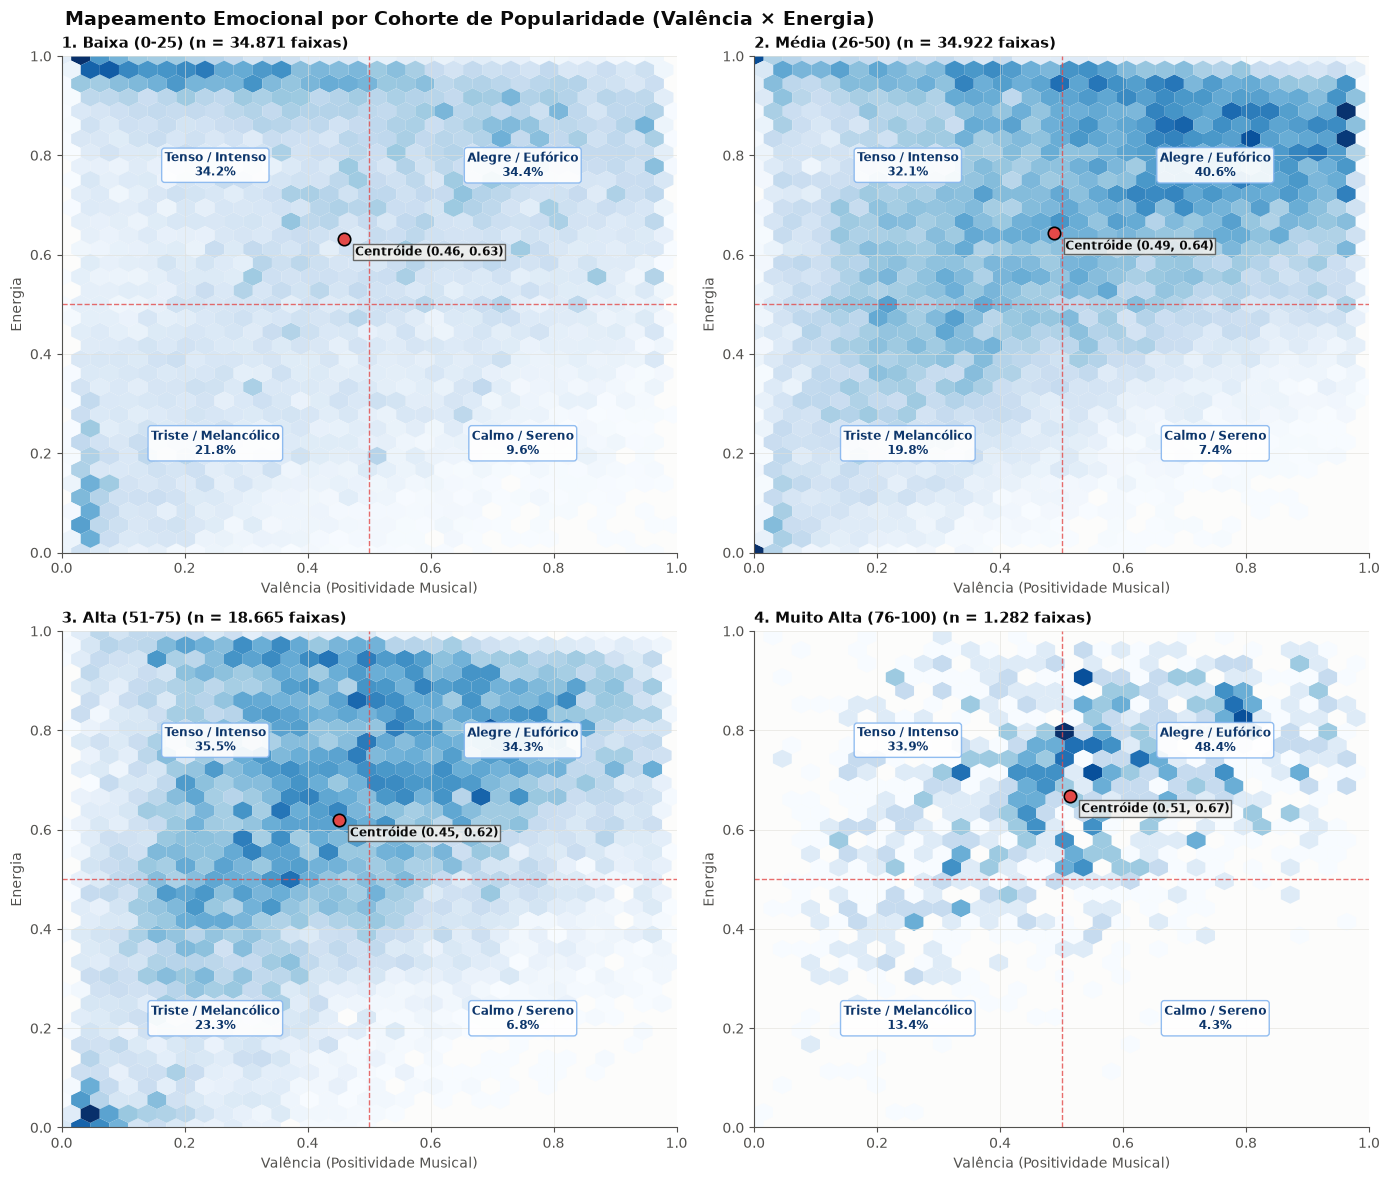

In [9]:
# Definição dos 4 cohortes de popularidade e dos quadrantes emocionais
df["cohorte_pop"] = pd.cut(
    df["popularity"],
    bins=[-1, 25, 50, 75, 100],
    labels=["1. Baixa (0-25)", "2. Média (26-50)", "3. Alta (51-75)", "4. Muito Alta (76-100)"]
)

df["quadrante"] = "Neutro"
df.loc[(df["valence"] >= 0.5) & (df["energy"] >= 0.5), "quadrante"] = "Alegre / Eufórico"
df.loc[(df["valence"] < 0.5) & (df["energy"] >= 0.5), "quadrante"] = "Tenso / Intenso"
df.loc[(df["valence"] < 0.5) & (df["energy"] < 0.5), "quadrante"] = "Triste / Melancólico"
df.loc[(df["valence"] >= 0.5) & (df["energy"] < 0.5), "quadrante"] = "Calmo / Sereno"

# Grid 2x2: Dispersão e Densidade 2D em cada Cohorte de Popularidade
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
cohortes = df["cohorte_pop"].cat.categories

for ax, coh in zip(axes.flat, cohortes):
    sub = df[df["cohorte_pop"] == coh]
    n_sub = len(sub)
    
    # Densidade 2D Hexbin
    ax.hexbin(sub["valence"], sub["energy"], gridsize=32, cmap="Blues", mincnt=1, edgecolors="none")
    
    # Divisórias dos quadrantes
    ax.axvline(0.5, color="#e34948", linestyle="--", linewidth=1.0, alpha=0.8)
    ax.axhline(0.5, color="#e34948", linestyle="--", linewidth=1.0, alpha=0.8)
    
    # Percentuais em cada quadrante para este cohorte
    q_counts = sub["quadrante"].value_counts()
    p_alegre = (q_counts.get("Alegre / Eufórico", 0) / n_sub) * 100
    p_tenso = (q_counts.get("Tenso / Intenso", 0) / n_sub) * 100
    p_triste = (q_counts.get("Triste / Melancólico", 0) / n_sub) * 100
    p_calmo = (q_counts.get("Calmo / Sereno", 0) / n_sub) * 100
    
    # Textos informativos dentro de cada quadrante
    ax.text(0.75, 0.78, f"Alegre / Eufórico\n{p_alegre:.1f}%", ha="center", va="center",
            fontsize=8.5, fontweight="bold", color="#0d366b",
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="#86b6ef", alpha=0.9))
    ax.text(0.25, 0.78, f"Tenso / Intenso\n{p_tenso:.1f}%", ha="center", va="center",
            fontsize=8.5, fontweight="bold", color="#0d366b",
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="#86b6ef", alpha=0.9))
    ax.text(0.25, 0.22, f"Triste / Melancólico\n{p_triste:.1f}%", ha="center", va="center",
            fontsize=8.5, fontweight="bold", color="#0d366b",
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="#86b6ef", alpha=0.9))
    ax.text(0.75, 0.22, f"Calmo / Sereno\n{p_calmo:.1f}%", ha="center", va="center",
            fontsize=8.5, fontweight="bold", color="#0d366b",
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="#86b6ef", alpha=0.9))
    
    # Centróide (média de valência e energia)
    v_mean = sub["valence"].mean()
    e_mean = sub["energy"].mean()
    ax.scatter([v_mean], [e_mean], color="#e34948", s=80, zorder=5, edgecolor="black", linewidth=1.2)
    ax.annotate(f"Centróide ({v_mean:.2f}, {e_mean:.2f})", xy=(v_mean, e_mean), xytext=(8, -12),
                textcoords="offset points", fontsize=8.5, fontweight="bold", color="#0b0b0b",
                bbox=dict(boxstyle="square,pad=0.15", fc="#f0efec", ec="#52514e", alpha=0.85))
    
    ax.set_title(f"{coh} (n = {n_sub:,} faixas)".replace(",", "."), loc="left",
                 fontsize=11, color="#0b0b0b", fontweight="bold")
    ax.set_xlabel("Valência (Positividade Musical)")
    ax.set_ylabel("Energia")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_facecolor("#fcfcfb")

fig.suptitle("Mapeamento Emocional por Cohorte de Popularidade (Valência × Energia)",
             x=0.05, ha="left", fontsize=14, color="#0b0b0b", fontweight="bold")
fig.tight_layout()
plt.show()

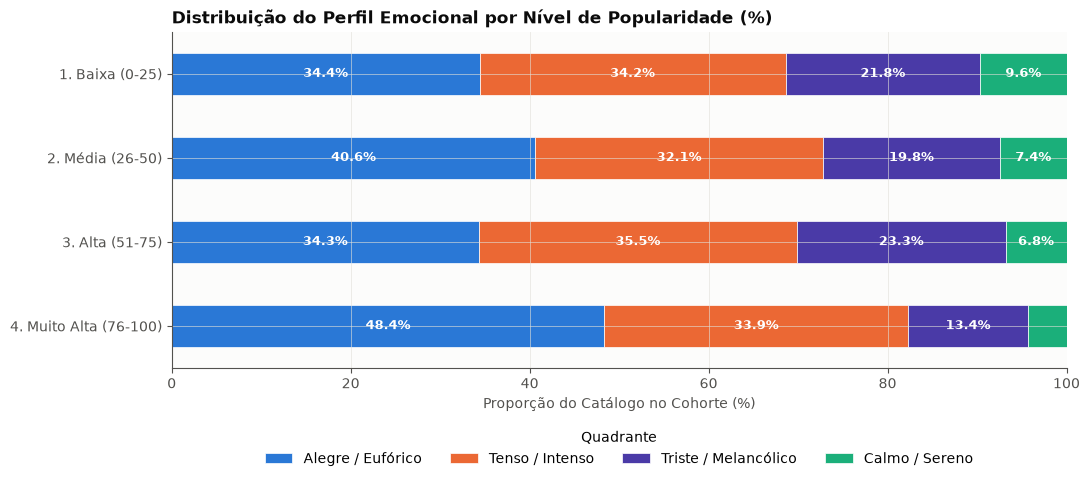

In [10]:
# Gráfico de Evolução dos Quadrantes Emocionais nos 4 Níveis de Popularidade
ct_quad = pd.crosstab(df["cohorte_pop"], df["quadrante"], normalize="index") * 100
ordem_q = ["Alegre / Eufórico", "Tenso / Intenso", "Triste / Melancólico", "Calmo / Sereno"]
ct_quad = ct_quad[ordem_q]
cores_quad = ["#2a78d6", "#eb6834", "#4a3aa7", "#1baf7a"]

fig, ax = plt.subplots(figsize=(11, 5))
ct_quad.plot(kind="barh", stacked=True, color=cores_quad, ax=ax, edgecolor="white", linewidth=0.5)

ax.set_title("Distribuição do Perfil Emocional por Nível de Popularidade (%)",
             loc="left", fontsize=12, color="#0b0b0b", fontweight="bold")
ax.set_xlabel("Proporção do Catálogo no Cohorte (%)")
ax.set_ylabel("")
ax.set_xlim(0, 100)
ax.legend(title="Quadrante", frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=4)
ax.set_facecolor("#fcfcfb")

for c_idx, bar in enumerate(ax.containers):
    for rect in bar:
        width = rect.get_width()
        if width > 6:
            ax.text(rect.get_x() + width / 2, rect.get_y() + rect.get_height() / 2,
                    f"{width:.1f}%", ha="center", va="center", color="white",
                    fontweight="bold", fontsize=9)

ax.invert_yaxis()
fig.tight_layout()
plt.show()

In [11]:
# Tabela Comparativa de Métricas Sonoras e Centróides por Cohorte
resumo_cohortes = df.groupby("cohorte_pop", observed=False).agg(
    faixas=("track_id", "count"),
    pop_media=("popularity", "mean"),
    valencia_media=("valence", "mean"),
    energia_media=("energy", "mean"),
    danceability_media=("danceability", "mean"),
    loudness_medio=("loudness", "mean"),
    acousticness_media=("acousticness", "mean"),
    instrumentalness_media=("instrumentalness", "mean")
).round(3)

# Adiciona colunas percentuais dos quadrantes
for q in ordem_q:
    resumo_cohortes[f"% {q}"] = ct_quad[q].round(1)

display(resumo_cohortes)

,faixas,pop_media,valencia_media,energia_media,danceability_media,loudness_medio,acousticness_media,instrumentalness_media,% Alegre / Eufórico,% Tenso / Intenso,% Triste / Melancólico,% Calmo / Sereno
cohorte_pop,,,,,,,,,,,,
1. Baixa (0-25),34871,12.192,0.459,0.632,0.545,-8.953,0.337,0.233,34.4,34.2,21.8,9.6
2. Média (26-50),34922,38.251,0.488,0.644,0.568,-8.213,0.332,0.146,40.6,32.1,19.8,7.4
3. Alta (51-75),18665,59.797,0.451,0.620,0.577,-8.329,0.313,0.125,34.3,35.5,23.3,6.8
4. Muito Alta (76-100),1282,80.346,0.514,0.668,0.641,-6.425,0.211,0.027,48.4,33.9,13.4,4.3


#### Leitura Analítica da Transição Emocional entre Cohortes:

1. **A 'Vantagem da Alegria/Euforia' no Topo Viral:** No estrato de popularidade *Muito Alta (76–100)*, o quadrante **Alegre / Eufórico (Alta Energia + Alta Valência)** atinge **48,4%** do total — um salto de **+14 pontos percentuais** em relação ao estrato de Baixa Popularidade (34,4%).
2. **A Barreira da Baixa Energia:** Os quadrantes de baixa energia (*Calmo / Sereno* e *Triste / Melancólico*) somam juntos **31,4%** das músicas no estrato Baixo, mas encolhem para apenas **17,7%** entre os hits de nível Muito Alto (com *Calmo/Sereno* caindo para escassos 4,3%).
3. **Migração do Centróide:** À medida que a popularidade sobe do nível Baixo para Muito Alto, o centróide acústico migra nitidamente para o quadrante superior direito (Valência média: $0,459 \to 0,514$; Energia média: $0,632 \to 0,668$), acompanhado por aumentos expressivos em **Danceability** ($0,545 \to 0,641$) e **Loudness** ($-8,95\text{ dB} \to -6,43\text{ dB}$).

## 4. Alavancas Estratégicas: Explícito, Colaboração e Multi-Gênero

Avaliamos como decisões artísticas e de posicionamento (feats, conteúdo explícito e cruzamento de gêneros) afetam a tração das faixas.

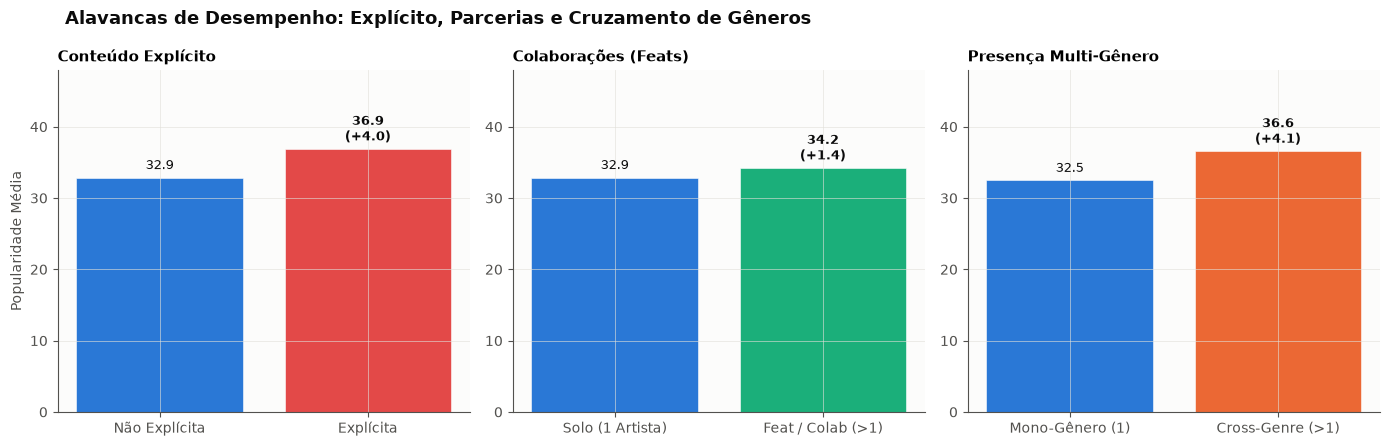

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# 1. Conteúdo Explícito
exp_df = df.groupby("explicit")["popularity"].mean()
axes[0].bar(["Não Explícita", "Explícita"], exp_df.values,
            color=["#2a78d6", "#e34948"], edgecolor="white", linewidth=0.4)
axes[0].set_title("Conteúdo Explícito", loc="left", fontsize=11, fontweight="bold")
axes[0].set_ylabel("Popularidade Média")
axes[0].set_ylim(0, 48)
for i, v in enumerate(exp_df.values):
    diff_txt = f"\n(+{v - exp_df.values[0]:.1f})" if i == 1 else ""
    axes[0].text(i, v + 1.2, f"{v:.1f}{diff_txt}", ha="center", fontsize=9,
                 color="#0b0b0b", fontweight="bold" if i == 1 else "normal")
axes[0].set_facecolor("#fcfcfb")

# 2. Colaboração (n_artistas > 1)
colab_df = df.groupby(df["n_artistas"] > 1)["popularity"].mean()
axes[1].bar(["Solo (1 Artista)", "Feat / Colab (>1)"], colab_df.values,
            color=["#2a78d6", "#1baf7a"], edgecolor="white", linewidth=0.4)
axes[1].set_title("Colaborações (Feats)", loc="left", fontsize=11, fontweight="bold")
axes[1].set_ylim(0, 48)
for i, v in enumerate(colab_df.values):
    diff_txt = f"\n(+{v - colab_df.values[0]:.1f})" if i == 1 else ""
    axes[1].text(i, v + 1.2, f"{v:.1f}{diff_txt}", ha="center", fontsize=9,
                 color="#0b0b0b", fontweight="bold" if i == 1 else "normal")
axes[1].set_facecolor("#fcfcfb")

# 3. Presença Cross-Genre (n_generos > 1)
cross_df = df.groupby(df["n_generos"] > 1)["popularity"].mean()
axes[2].bar(["Mono-Gênero (1)", "Cross-Genre (>1)"], cross_df.values,
            color=["#2a78d6", "#eb6834"], edgecolor="white", linewidth=0.4)
axes[2].set_title("Presença Multi-Gênero", loc="left", fontsize=11, fontweight="bold")
axes[2].set_ylim(0, 48)
for i, v in enumerate(cross_df.values):
    diff_txt = f"\n(+{v - cross_df.values[0]:.1f})" if i == 1 else ""
    axes[2].text(i, v + 1.2, f"{v:.1f}{diff_txt}", ha="center", fontsize=9,
                 color="#0b0b0b", fontweight="bold" if i == 1 else "normal")
axes[2].set_facecolor("#fcfcfb")

fig.suptitle("Alavancas de Desempenho: Explícito, Parcerias e Cruzamento de Gêneros",
             x=0.05, ha="left", fontsize=13, color="#0b0b0b", fontweight="bold")
fig.tight_layout()
plt.show()

## 5. Anatomia dos Gêneros Musicais

Análise da diversidade e dos rankings de popularidade dos gêneros.
Para evitar o viés da partição arbitrária (`genero_principal`), usamos a base longa (`df_long`) onde cada faixa pontua legitimamente em cada gênero a que pertence.

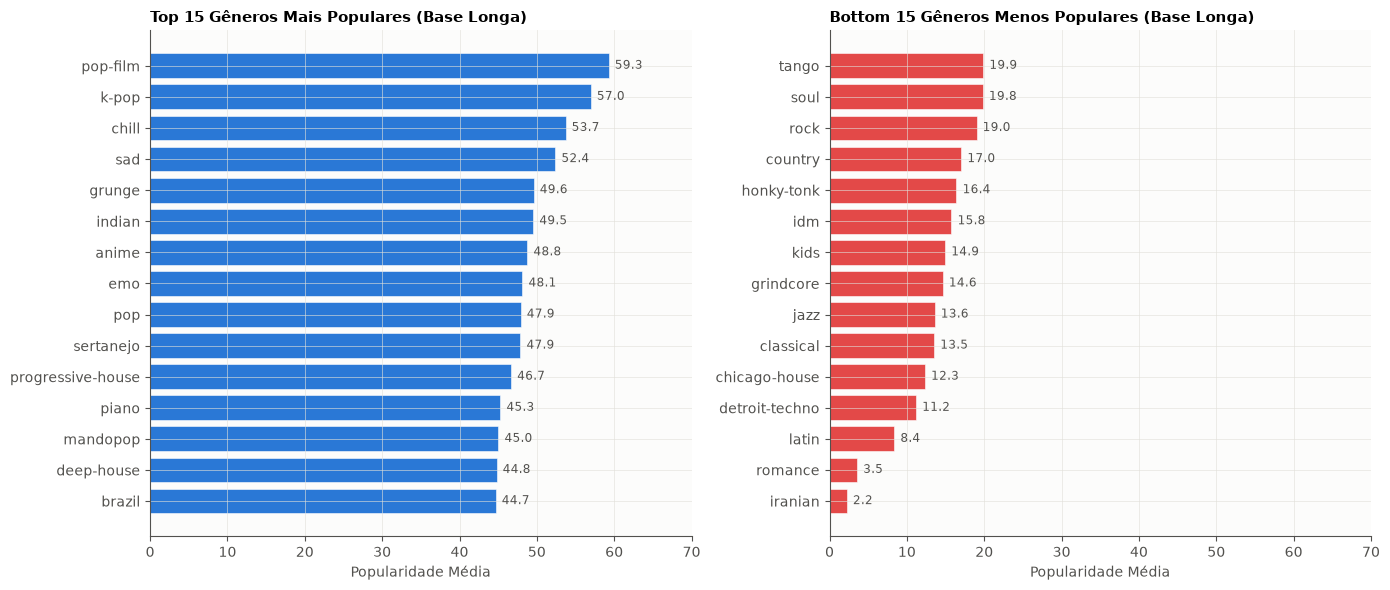

In [13]:
# Popularidade por gênero na base longa (sem distorção de chave arbitrária)
pop_gen_long = (df_long.groupby("track_genre")
                       .agg(faixas=("track_id", "count"),
                            pop_media=("popularity", "mean"),
                            pop_mediana=("popularity", "median"))
                       .sort_values("pop_media", ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top15 = pop_gen_long.head(15).sort_values("pop_media")
axes[0].barh(top15.index, top15["pop_media"], color="#2a78d6", edgecolor="white", linewidth=0.4)
axes[0].set_title("Top 15 Gêneros Mais Populares (Base Longa)", loc="left", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Popularidade Média")
axes[0].set_xlim(0, 70)
for i, (g, row) in enumerate(top15.iterrows()):
    axes[0].text(row["pop_media"] + 0.8, i, f"{row['pop_media']:.1f}",
                 va="center", fontsize=8.5, color="#52514e")
axes[0].set_facecolor("#fcfcfb")

bottom15 = pop_gen_long.tail(15).sort_values("pop_media", ascending=True)
axes[1].barh(bottom15.index, bottom15["pop_media"], color="#e34948", edgecolor="white", linewidth=0.4)
axes[1].set_title("Bottom 15 Gêneros Menos Populares (Base Longa)", loc="left", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Popularidade Média")
axes[1].set_xlim(0, 70)
for i, (g, row) in enumerate(bottom15.iterrows()):
    axes[1].text(row["pop_media"] + 0.8, i, f"{row['pop_media']:.1f}",
                 va="center", fontsize=8.5, color="#52514e")
axes[1].set_facecolor("#fcfcfb")

fig.tight_layout()
plt.show()

### 5.1 Perfil Sonoro dos Top 10 Gêneros

Heatmap multidimensional comparando o *fingerprint* acústico dos 10 gêneros líderes em popularidade.

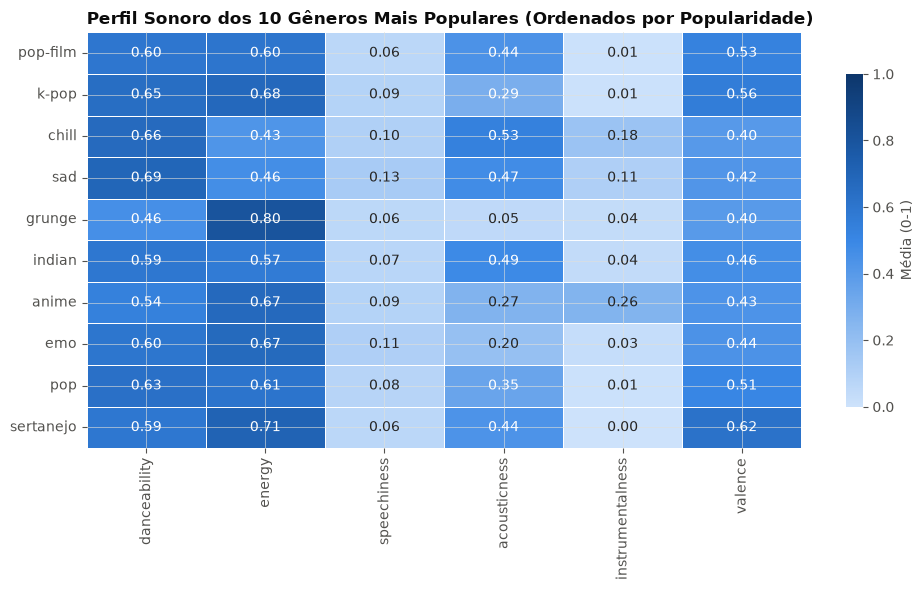

In [14]:
FEATS_RADAR = ["danceability", "energy", "speechiness", "acousticness", "instrumentalness", "valence"]
top10_pop = pop_gen_long.head(10).index.tolist()

perfil = df_long[df_long["track_genre"].isin(top10_pop)].groupby("track_genre")[FEATS_RADAR].mean()
perfil = perfil.reindex(top10_pop)

fig, ax = plt.subplots(figsize=(10, 6))
cmap = mpl.colors.LinearSegmentedColormap.from_list(
    "seq_blue", ["#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"])
sns.heatmap(perfil, annot=True, fmt=".2f", cmap=cmap, vmin=0, vmax=1,
            cbar_kws={"shrink": 0.8, "label": "Média (0-1)"},
            linewidths=0.5, linecolor="white", ax=ax)
ax.set_title("Perfil Sonoro dos 10 Gêneros Mais Populares (Ordenados por Popularidade)",
             loc="left", fontsize=12, color="#0b0b0b", fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_facecolor("#fcfcfb")
fig.tight_layout()
plt.show()

## 6. Correlações entre Variáveis Numéricas

Avaliamos a interdependência entre atributos sonoros e o poder explicativo linear de cada variável sobre a popularidade.

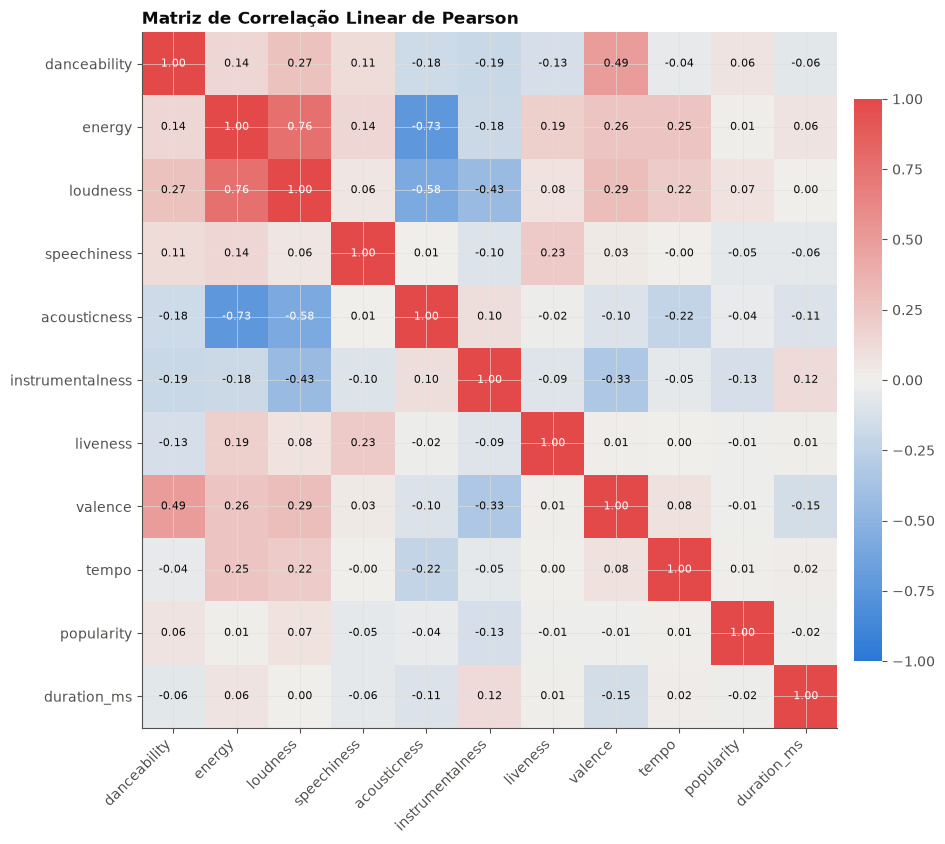

In [15]:
CORR_COLS = FEATURES + ["popularity", "duration_ms"]
corr = df[CORR_COLS].corr()

fig, ax = plt.subplots(figsize=(10, 8.5))
cmap = mpl.colors.LinearSegmentedColormap.from_list(
    "div_blue_red", ["#2a78d6", "#f0efec", "#e34948"])
im = ax.imshow(corr, cmap=cmap, vmin=-1, vmax=1, aspect="equal")
ax.set_xticks(range(len(CORR_COLS)))
ax.set_yticks(range(len(CORR_COLS)))
ax.set_xticklabels(CORR_COLS, rotation=45, ha="right")
ax.set_yticklabels(CORR_COLS)
for i in range(len(CORR_COLS)):
    for j in range(len(CORR_COLS)):
        v = corr.iloc[i, j]
        cor_texto = "white" if abs(v) > 0.55 else "#0b0b0b"
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8, color=cor_texto)

cbar = fig.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
cbar.outline.set_visible(False)
ax.set_title("Matriz de Correlação Linear de Pearson",
             loc="left", fontsize=12, color="#0b0b0b", fontweight="bold")
ax.set_facecolor("#fcfcfb")
fig.tight_layout()
plt.show()

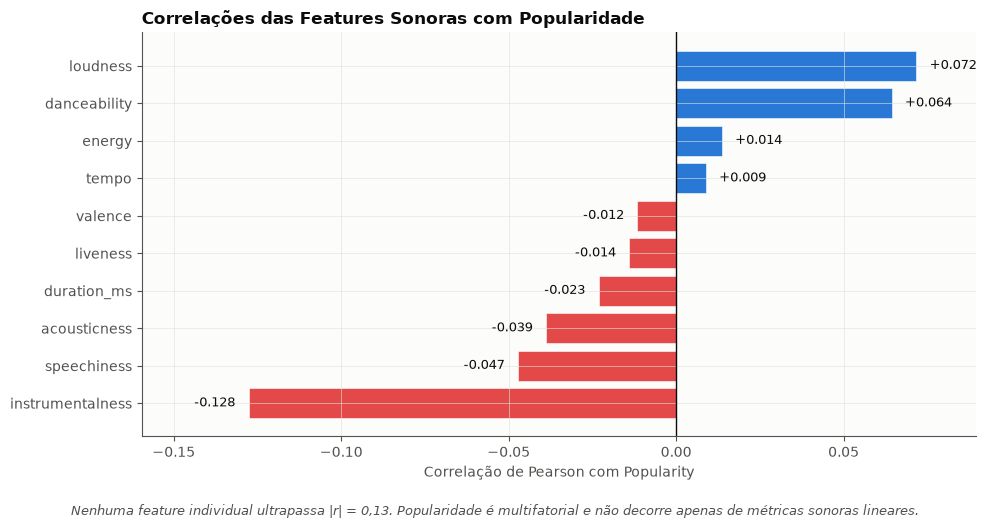

In [16]:
corr_pop = corr["popularity"].drop("popularity").sort_values()
fig, ax = plt.subplots(figsize=(10, 5))
cores = ["#e34948" if v < 0 else "#2a78d6" for v in corr_pop.values]
ax.barh(corr_pop.index, corr_pop.values, color=cores, edgecolor="white", linewidth=0.4)
ax.axvline(0, color="#0b0b0b", linewidth=1)
for i, (feat, v) in enumerate(corr_pop.items()):
    ax.text(v + (0.004 if v >= 0 else -0.004), i, f"{v:+.3f}",
            va="center", ha="left" if v >= 0 else "right",
            fontsize=9, color="#0b0b0b")

ax.set_xlim(corr_pop.min() * 1.25, corr_pop.max() * 1.25)
ax.set_xlabel("Correlação de Pearson com Popularity")
ax.set_title("Correlações das Features Sonoras com Popularidade",
             loc="left", fontsize=12, color="#0b0b0b", fontweight="bold")
ax.set_facecolor("#fcfcfb")
fig.text(0.5, -0.04,
         "Nenhuma feature individual ultrapassa |r| = 0,13. Popularidade é multifatorial e não decorre apenas de métricas sonoras lineares.",
         ha="center", fontsize=9, color="#52514e", style="italic")
fig.tight_layout()
plt.show()

## 7. Duração das Faixas

Analisamos a distribuição de duração e a estabilidade da faixa ótima de execução comercial (2,5 a 5 minutos).

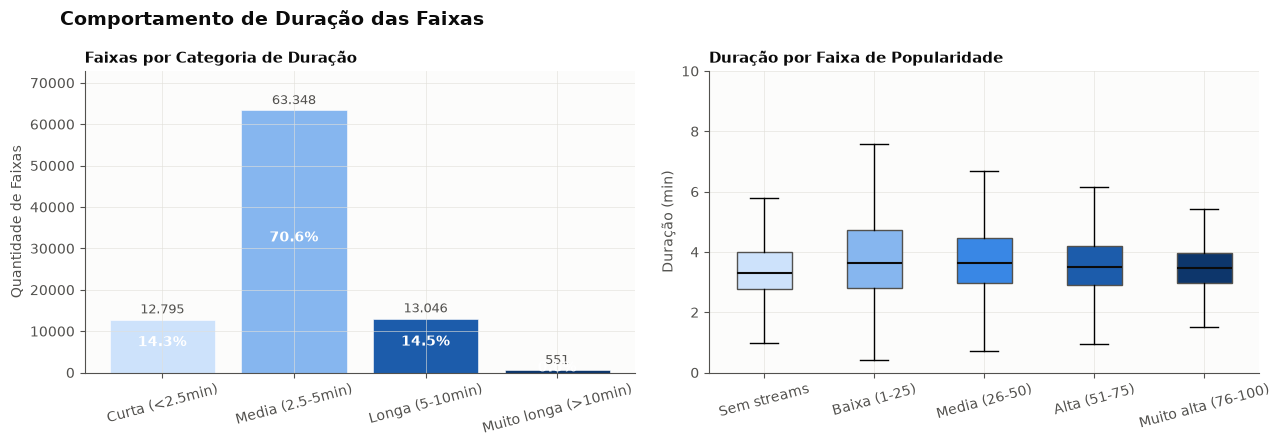

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ordem = ["Curta (<2.5min)", "Media (2.5-5min)", "Longa (5-10min)", "Muito longa (>10min)"]
cont = df["duracao_categoria"].value_counts().reindex(ordem)
cores = ["#cde2fb", "#86b6ef", "#1c5cab", "#0d366b"]
axes[0].bar(cont.index, cont.values, color=cores, edgecolor="white", linewidth=0.4)
for i, v in enumerate(cont.values):
    axes[0].text(i, v + 1500, f"{v:,}".replace(",", "."), ha="center", fontsize=9, color="#52514e")
    pct = v / cont.sum() * 100
    axes[0].text(i, v / 2, f"{pct:.1f}%", ha="center", color="white", fontweight="bold", fontsize=10)
axes[0].set_title("Faixas por Categoria de Duração", loc="left", fontsize=11, color="#0b0b0b", fontweight="bold")
axes[0].set_ylabel("Quantidade de Faixas")
axes[0].set_ylim(0, cont.max() * 1.15)
axes[0].tick_params(axis="x", rotation=15)
axes[0].set_facecolor("#fcfcfb")

ordem_pop = ["Sem streams", "Baixa (1-25)", "Media (26-50)", "Alta (51-75)", "Muito alta (76-100)"]
dados = [df.loc[df["popularidade_faixa"] == c, "duracao_min"].dropna().values for c in ordem_pop]
bp = axes[1].boxplot(dados, tick_labels=ordem_pop, patch_artist=True,
                     medianprops={"color": "#0b0b0b", "linewidth": 1.5},
                     flierprops={"marker": "", "markersize": 0})
for patch, cor in zip(bp["boxes"], ["#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"]):
    patch.set_facecolor(cor)
    patch.set_edgecolor("#52514e")
axes[1].set_ylim(0, 10)
axes[1].set_ylabel("Duração (min)")
axes[1].set_title("Duração por Faixa de Popularidade", loc="left", fontsize=11, color="#0b0b0b", fontweight="bold")
axes[1].tick_params(axis="x", rotation=15)
axes[1].set_facecolor("#fcfcfb")

fig.suptitle("Comportamento de Duração das Faixas",
             x=0.05, ha="left", fontsize=14, color="#0b0b0b", fontweight="bold")
fig.tight_layout()
plt.show()

## 8. Artistas — Volume de Catálogo × Popularidade Média

Investigamos a relação entre a quantidade de lançamentos por artista e sua popularidade média.

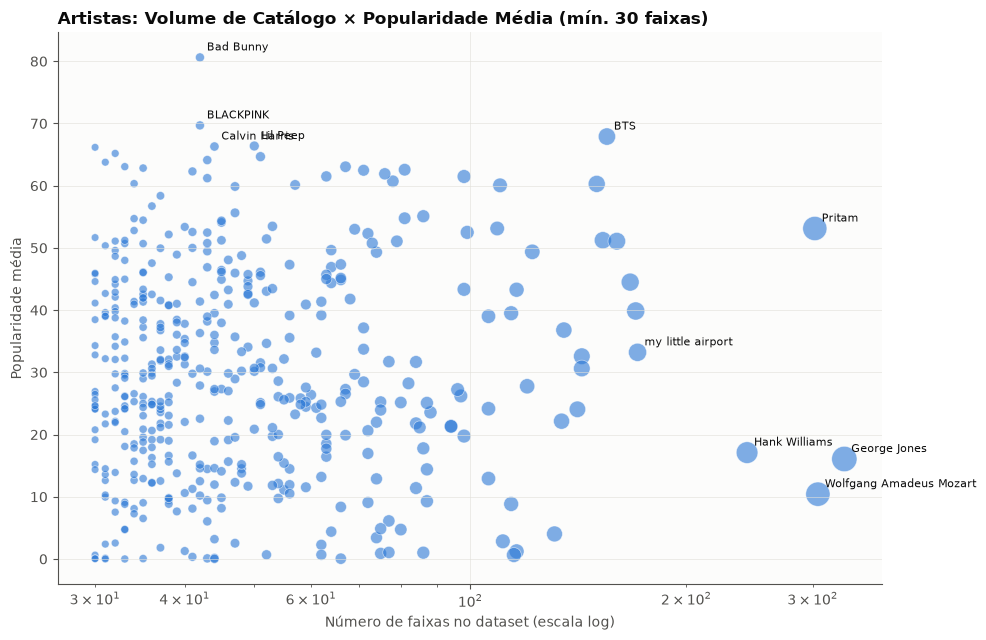

In [18]:
artistas = (df.groupby("artista_principal")
                 .agg(n=("track_id", "count"),
                      pop_media=("popularity", "mean"))
                 .query("n >= 30"))

fig, ax = plt.subplots(figsize=(10, 6.5))
ax.scatter(artistas["n"], artistas["pop_media"],
           s=artistas["n"], c="#2a78d6", alpha=0.6, edgecolor="white", linewidth=0.5)
ax.set_xscale("log")
ax.set_xlabel("Número de faixas no dataset (escala log)")
ax.set_ylabel("Popularidade média")
ax.set_title("Artistas: Volume de Catálogo × Popularidade Média (mín. 30 faixas)",
             loc="left", fontsize=12, color="#0b0b0b", fontweight="bold")
ax.set_facecolor("#fcfcfb")

top_mais = artistas.nlargest(5, "n")
top_pop = artistas.nlargest(5, "pop_media")
for label, row in pd.concat([top_mais, top_pop]).drop_duplicates().iterrows():
    ax.annotate(label,
                xy=(row["n"], row["pop_media"]),
                xytext=(5, 5), textcoords="offset points",
                fontsize=8, color="#0b0b0b")
fig.tight_layout()
plt.show()

## 9. Tonalidade e Modo Musical

Distribuição harmônica em escala cromática (12 semitons) e associação entre Modo (Maior/Menor) e Faixas de Popularidade.

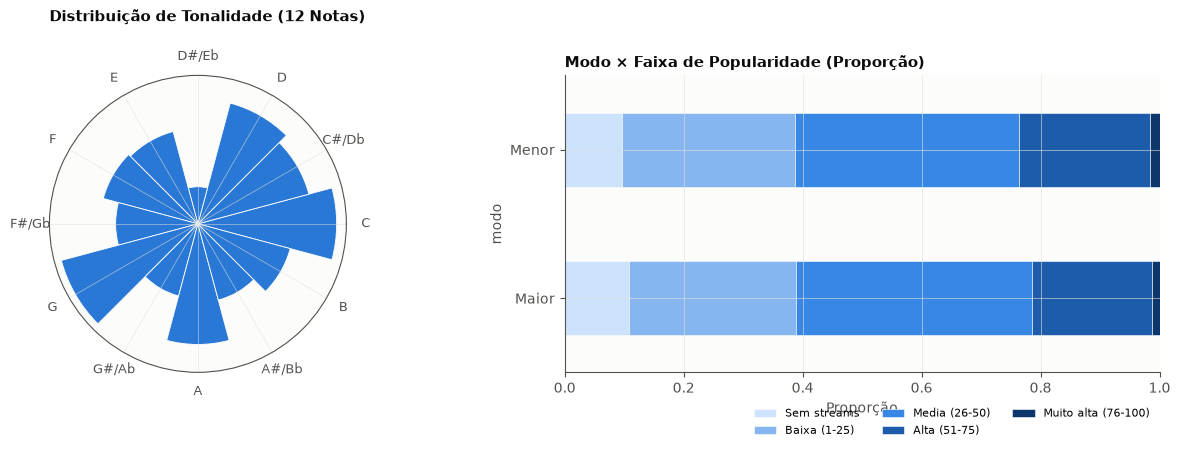

In [19]:
NOTAS = ["C", "C#/Db", "D", "D#/Eb", "E", "F", "F#/Gb",
         "G", "G#/Ab", "A", "A#/Bb", "B"]

fig = plt.figure(figsize=(13, 4.8))
ax_polar = fig.add_subplot(1, 2, 1, projection="polar")
ax_cart = fig.add_subplot(1, 2, 2)

cont_t = df["tonalidade"].value_counts().reindex(NOTAS).fillna(0)
ang = np.linspace(0, 2 * np.pi, len(NOTAS), endpoint=False)
ax_polar.bar(ang, cont_t.values, width=2 * np.pi / len(NOTAS),
             color="#2a78d6", edgecolor="white", linewidth=0.6, align="center")
ax_polar.set_xticks(ang)
ax_polar.set_xticklabels(NOTAS, fontsize=9)
ax_polar.set_yticks([])
ax_polar.set_title("Distribuição de Tonalidade (12 Notas)",
                   loc="left", fontsize=11, color="#0b0b0b", fontweight="bold", pad=20)
ax_polar.grid(color="#e1e0d9", linewidth=0.5)
ax_polar.set_facecolor("#fcfcfb")

ordem = ["Sem streams", "Baixa (1-25)", "Media (26-50)", "Alta (51-75)", "Muito alta (76-100)"]
cores = ["#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"]
ct = pd.crosstab(df["modo"], df["popularidade_faixa"], normalize="index")[ordem]
ct.plot(kind="barh", stacked=True, color=cores, ax=ax_cart,
        edgecolor="white", linewidth=0.4, legend=True)
ax_cart.set_xlabel("Proporção")
ax_cart.set_xlim(0, 1)
ax_cart.set_title("Modo × Faixa de Popularidade (Proporção)",
                  loc="left", fontsize=11, color="#0b0b0b", fontweight="bold")
ax_cart.legend(title=None, frameon=False, loc="lower right", fontsize=8,
               bbox_to_anchor=(1.0, -0.25), ncol=3)
ax_cart.set_facecolor("#fcfcfb")
fig.tight_layout()
plt.show()

## 10. Síntese Executiva dos Achados

Consolidação dos principais indicadores e conclusões de negócio extraídos da EDA:

| Indicador / Métrica | Valor Encontrado |
|---|---|
| Faixas únicas analisadas | **89.740** (redução legítima de 21% vs 114k brutos) |
| Faixas multi-gênero (`n_generos > 1`) | **18,2%** |
| Faixas sem streams (`popularity == 0`) | **9.347 (10,4%)** |
| Faixas de altíssima popularidade (`popularity >= 76`) | **1.282 (1,4%)** |
| Faixas em modo maior | **63,7%** |
| Faixas instrumentais (`instrumentalness > 0,5`) | **18,5%** |
| Faixas ao vivo (`liveness > 0,8`) | **3,2%** |
| Faixas explícitas | **8,6%** |
| Faixas com múltiplos artistas (colabs/feats) | **25,2%** |
| Ganho de popularidade mediana em Colabs | **+5,0 pontos** (37 vs 32) |
| Ganho de popularidade mediana em Cross-Genre | **+12,0 pontos** (43 vs 31) |
| Queda de instrumentalness no Top 5% Hits | **-78,3%** (0,039 vs 0,181) |
| Duração mediana geral | **3,56 min** (70% entre 2,5 e 5 min) |

---

### Principais Conclusões para o Spotify Challenge (Grupo 4):

1. **A 'Fórmula Acústica' do Hit existe, mas é sutil:** O Top 5% mais popular não é necessariamente muito mais rápido ou feliz, mas é **quase estritamente vocal** (queda de 78% em `instrumentalness`), **menos acústico/mais eletrônico** (-27%), **mais comprimido/alto** (+19% em `loudness`) e **mais dançável** (+10%).
2. **O Efeito Colaboração e Cross-Genre:** Artistas que realizam feats (`n_artistas > 1`) e músicas que circulam em múltiplos gêneros (`n_generos > 1`) obtêm aumentos substanciais de tração (mediana salta de 31 para 43 pontos no caso multi-gênero).
3. **Limites da Previsão Linear:** Correlações univariadas com popularidade não ultrapassam $|r| = 0,13$. Isso demonstra categoricamente que a popularidade de uma faixa não pode ser prevista puramente por regressão linear sobre features sonoras isoladas — fatores contextuais, de marketing, base de fãs e playlisting são determinantes.
4. **Estratificação Artificial do Dataset:** O dataset original foi balanceado com ~1.000 faixas por gênero (113 gêneros). Análises que dependem do tamanho do gênero são recortes do dataset, e comparações de popularidade por gênero devem ser feitas na base longa desduplicada.

## 11. Próximos Passos Sugeridos

- **Clusterização Não Supervisionada (K-Means / HDBSCAN):** Agrupar músicas no espaço latente de features sonoras e avaliar se os clusters recuperam famílias de gêneros ou moods.
- **Modelagem Preditiva Não-Linear:** Treinar modelos baseados em árvores (Random Forest / XGBoost / LightGBM) para prever popularidade contínua ou classificação binária de Hits, avaliando a importância das features (SHAP values).